In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# The Bernstein-Vazirani Algorithm

### 1. Problem Statement
The Bernstein-Vazirani (BV) algorithm evaluates a black-box function (an Oracle) $f(x)$ that hides a secret $n$-bit binary string $s = s_{n-1}...s_1s_0$. The function computes the bitwise dot product of the input $x$ and the secret string $s$, modulo 2:
$$f(x) = x \cdot s \pmod 2 = (x_0s_0 \oplus x_1s_1 \oplus ... \oplus x_{n-1}s_{n-1})$$

The objective is to find the exact hidden string $s$ using the absolute minimum number of queries to the Oracle.

### 2. Quantum Advantage: $O(n)$ vs $O(1)$
* **Classical Complexity:** A classical computer must query the Oracle $n$ times to guarantee the discovery of $s$. It evaluates inputs with a single `1` at each bit position (e.g., $x = 00...01$, then $x = 00...10$) to reveal the string bit-by-bit. This results in $O(n)$ complexity.
* **Quantum Complexity:** The BV algorithm exploits quantum superposition and phase kickback to evaluate the global structure of the function simultaneously. It securely recovers the entire $n$-bit string $s$ with a $100\%$ probability of success in exactly **one** query, demonstrating $O(1)$ complexity.

### 3. Step-by-Step Mathematical Evolution

The algorithm deterministically maps the phases generated by the Oracle back into the computational basis state representing $s$.

**Step 1: State Initialization**
We initialize an $n$-qubit input register to $|0\rangle$ and a single-qubit auxiliary target register to $|1\rangle$.
$$|\psi_0\rangle = |0\rangle^{\otimes n} \otimes |1\rangle$$

**Step 2: Full Superposition**
Hadamard ($H$) gates are applied to all $n+1$ qubits. The input register enters a uniform superposition, and the target qubit is prepared in the $|-\rangle$ state to enable phase kickback.
$$|\psi_1\rangle = |+\rangle^{\otimes n} \otimes |-\rangle = \left( \frac{1}{\sqrt{2^n}} \sum_{x \in \{0,1\}^n} |x\rangle \right) \otimes |-\rangle$$

**Step 3: Oracle Evaluation (Phase Kickback)**
The unitary Oracle $U_f$ is applied. Because the target qubit is in the $|-\rangle$ state, the operation $U_f |x\rangle |-\rangle$ kicks back a phase of $(-1)^{f(x)}$ to the input register, rather than flipping the target state vector.
$$|\psi_2\rangle = \left( \frac{1}{\sqrt{2^n}} \sum_{x \in \{0,1\}^n} (-1)^{f(x)} |x\rangle \right) \otimes |-\rangle$$
Substituting the Oracle's definition $f(x) = s \cdot x$:
$$|\psi_2\rangle = \left( \frac{1}{\sqrt{2^n}} \sum_{x \in \{0,1\}^n} (-1)^{s \cdot x} |x\rangle \right) \otimes |-\rangle$$

**Step 4: Quantum Interference (Inverse QFT)**
A final layer of Hadamard gates is applied to the input register. The Hadamard transform perfectly constructively interferes at the exact computational basis state corresponding to the hidden string $s$, while destructively interfering at all other possible states.
$$|\psi_3\rangle = |s\rangle \otimes |-\rangle$$

Upon measurement of the input register, the state collapses to $|s\rangle$ with absolute certainty.

### 4. Implementation Architecture

**Encoding the Secret String ($s$)**
In a quantum circuit, the dot product $x \cdot s$ is physically realized using `CNOT` gates. We iterate through the desired secret string $s$. For every bit $s_i = 1$, we apply a `CNOT` gate where the control is the $i$-th qubit in the input register ($q_i$) and the target is the auxiliary qubit.

**Critical Implementation Note: The Target Qubit State**
For phase kickback to function, the target qubit *must* enter the Oracle in the $|-\rangle$ state. 
* If the target qubit is initialized to $|1\rangle$ but the Hadamard gate is omitted, it enters the Oracle as $|1\rangle$. 
* Applying a `CNOT` to a $|1\rangle$ target flips it to $|0\rangle$. This creates classical entanglement between the control and target registers rather than inducing a relative phase shift.
* Without the accumulation of $(-1)$ phases, the final layer of Hadamard gates will simply map the uniform $|+\rangle^{\otimes n}$ state back to the all-zeros basis state $|00...0\rangle$, resulting in algorithm failure.

In [10]:
def build_bv_circuit(secret_string: str) -> QuantumCircuit:
    n = len(secret_string)
    qr = QuantumRegister(n+1, 'q')
    cr = ClassicalRegister(n, 'c')
    qc = QuantumCircuit(qr,cr)

    qc.x(n) # flip target bit to |1>
    qc.barrier()

    qc.h(range(n+1))
    qc.barrier()

    reversed_s = secret_string[::-1]
    for i in range(n):
        if reversed_s[i] == '1':
            qc.cx(i,n)  # Control: q_i, Target: q_n (the auxiliary qubit)
    qc.barrier()

    for i in range(n):
        qc.h(i)
    qc.barrier()

    for i in range(n):
        qc.measure(i, i)
        
    return qc
        

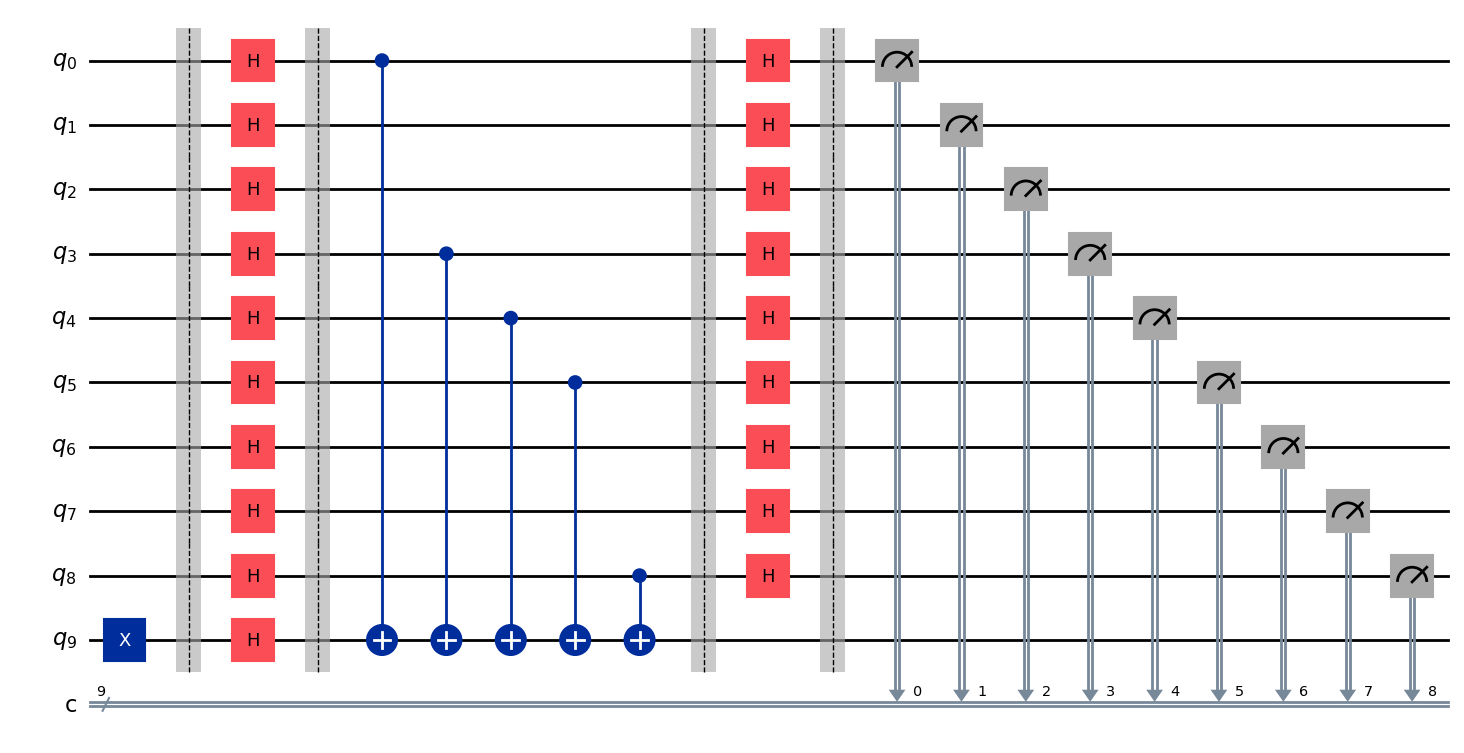

In [15]:
secret_string = '100111001'
bv_circuit = build_bv_circuit(secret_string)
bv_circuit.draw('mpl')

In [16]:
sim = AerSimulator()
job = sim.run(bv_circuit, shots = 1)
result = job.result()
counts = result.get_counts()
print(f"Secret String: {secret_string}")
print(f"Measurement Output: {counts}")


Secret String: 100111001
Measurement Output: {'100111001': 1}
